#### Import des librairies

In [1]:
import pandas as pd
from tqdm import tqdm
import numpy as np

In [2]:
path_file = '~/Bureau/exports/20241112/AGS_20241112_exports_agronomes_-archive/AGS_20241112_exports_agronomes_assolees_synthetisees.csv'

ENTREPOT_PATH = '~/Bureau/utils/data/'
df = {}

#### Import des données

In [3]:
# ------------------ #
# IMPORT DES DONNÉES #
# ------------------ #


def import_df(df_name, path_data, sep, index_col=None):
    df[df_name] = pd.read_csv(path_data+df_name+'.csv', sep = sep, index_col=index_col, low_memory=False).replace({'\r\n': '\n'}, regex=True)

def import_dfs(df_names, path_data, sep = ',', index_col=None, verbose=False):
    for df_name in tqdm(df_names) : 
        if(verbose) :
            print(" - ", df_name)
        import_df(df_name, path_data, sep, index_col=index_col)

tables_with_id = [
    'sdc', 
    'dispositif', 
    'domaine',
    'commune',
]

tables_without_id = [
    'sdc_realise_performance',
    'agreste_ift_gcpe_reference_region'
]

# import des données de l'entrepôt avec la colonne 'id' en index 
import_dfs(tables_with_id, ENTREPOT_PATH, sep = ',', index_col='id', verbose=False)

# import des données du magasin
import_dfs(tables_without_id, ENTREPOT_PATH, sep = ',', verbose=False)

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:01<00:00,  1.65it/s]


## Ajout des informations

In [4]:
left = df['sdc_realise_performance'][['sdc_id', 'ift_cible_non_mil_chimique_tot']]
right = df['sdc'][['dispositif_id', 'filiere', 'type_agriculture']]
df['sdc_realise_performance_extanded'] = pd.merge(left, right, left_on = 'sdc_id', right_index=True, how='left')

left = df['sdc_realise_performance_extanded']
right = df['dispositif'][['domaine_id']]
df['sdc_realise_performance_extanded'] = pd.merge(left, right, left_on = 'dispositif_id', right_index=True, how='left')

left = df['sdc_realise_performance_extanded']
right = df['domaine'][['commune_id', 'campagne']]
df['sdc_realise_performance_extanded'] = pd.merge(left, right, left_on = 'domaine_id', right_index=True, how='left')

left = df['sdc_realise_performance_extanded']
right = df['commune'][['ancienne_region']]
df['sdc_realise_performance_extanded'] = pd.merge(left, right, left_on = 'commune_id', right_index=True, how='left')

left = df['sdc_realise_performance_extanded'][
    ['sdc_id', 'campagne', 'ancienne_region', 'ift_cible_non_mil_chimique_tot', 'filiere', 'type_agriculture']
]
right = df['agreste_ift_gcpe_reference_region']
df['sdc_realise_performance_extanded'] = pd.merge(left, right, left_on=['ancienne_region', 'campagne'], right_on=['nom_ancienne_region', 'campagne'], how='left')

df['sdc_realise_performance_extanded'] = df['sdc_realise_performance_extanded'].set_index('sdc_id')

## Filtres

In [5]:
df['sdc_realise_performance_gcpe'] = df['sdc_realise_performance_extanded'].loc[
    (df['sdc_realise_performance_extanded']['filiere'] == 'GRANDES_CULTURES') | 
    (df['sdc_realise_performance_extanded']['filiere'] == 'POLYCULTURE_ELEVAGE')
]

df['sdc_realise_performance_gcpe_conv'] = df['sdc_realise_performance_gcpe'].loc[
    (df['sdc_realise_performance_gcpe']['type_agriculture'] == 'Agriculture conventionnelle') 
]

df['sdc_realise_performance_gcpe_conv'] = df['sdc_realise_performance_gcpe_conv'].loc[
    df['sdc_realise_performance_gcpe_conv']['ift_cible_non_mil_chimique_tot'] < 30
]

df['sdc_realise_performance_gcpe_conv'] = df['sdc_realise_performance_gcpe_conv'].loc[
    (df['sdc_realise_performance_gcpe_conv']['campagne'] >= 2012) & 
    (df['sdc_realise_performance_gcpe_conv']['campagne'] < 2026)
]

## Renommages

In [6]:
df['sdc_realise_performance_gcpe_conv'] = df['sdc_realise_performance_gcpe_conv'].rename(columns={
    'ift_moyen_gcpe_can' : 'ift_region_agreste_can'
})

In [7]:
df['sdc_realise_performance_gcpe_conv'].loc[
    (df['sdc_realise_performance_gcpe_conv']['ancienne_region'] == 'Bourgogne') &
    (df['sdc_realise_performance_gcpe_conv']['campagne'] == 2025)
]['ift_cible_non_mil_chimique_tot'].mean()

np.float64(1.8601009418478351)

## Affichage

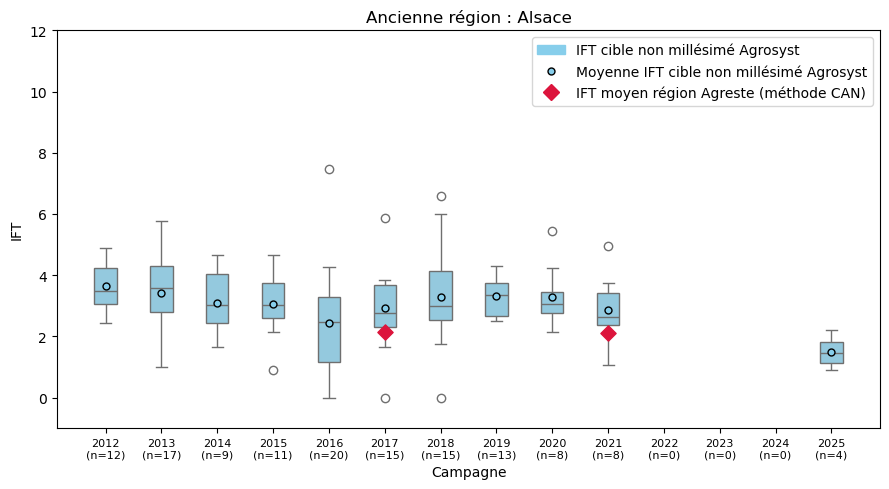

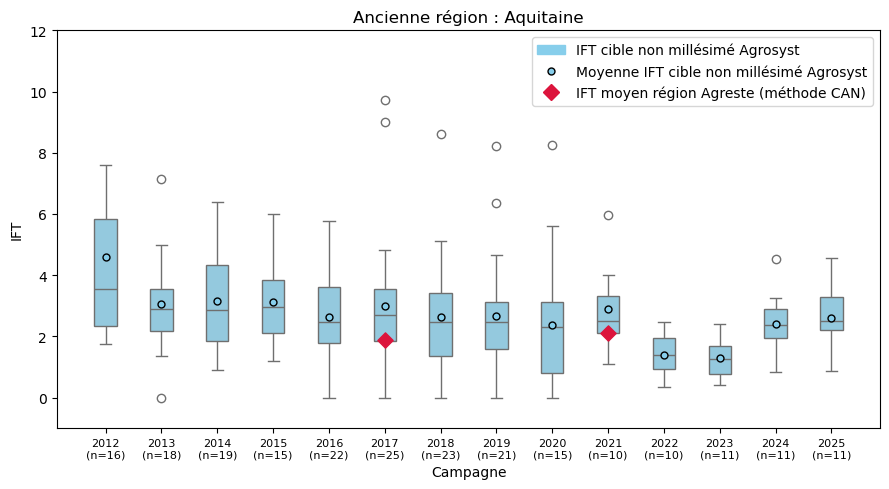

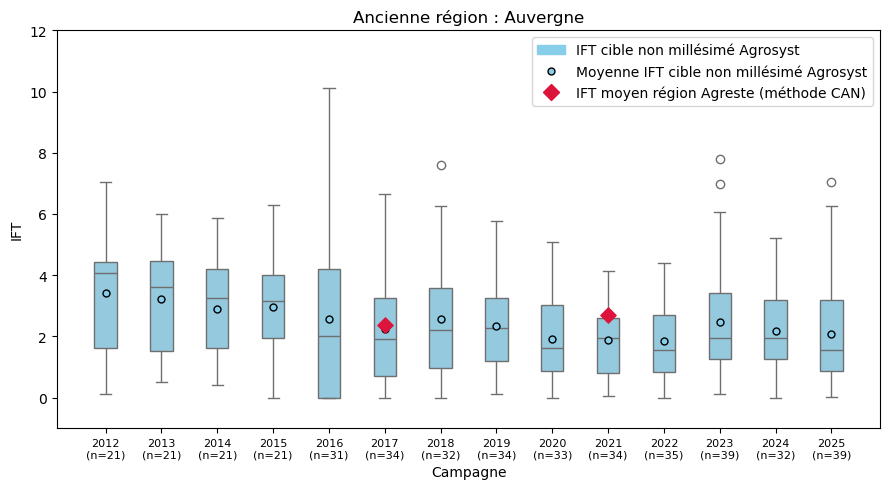

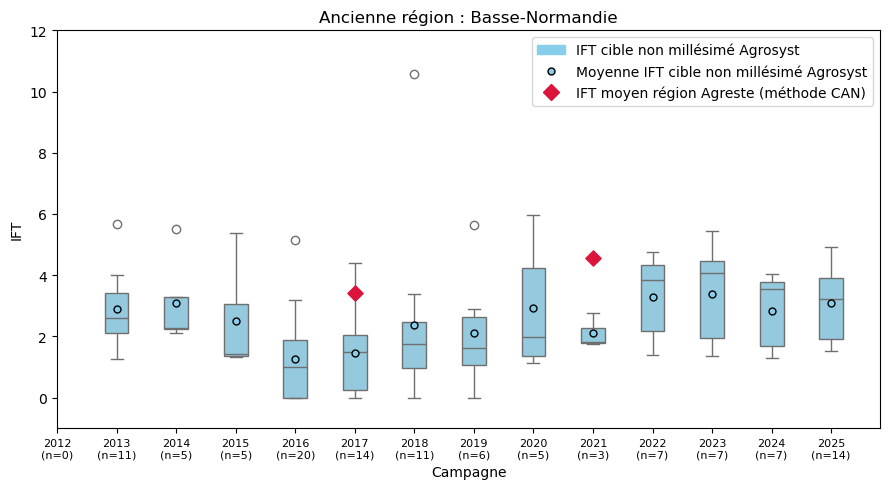

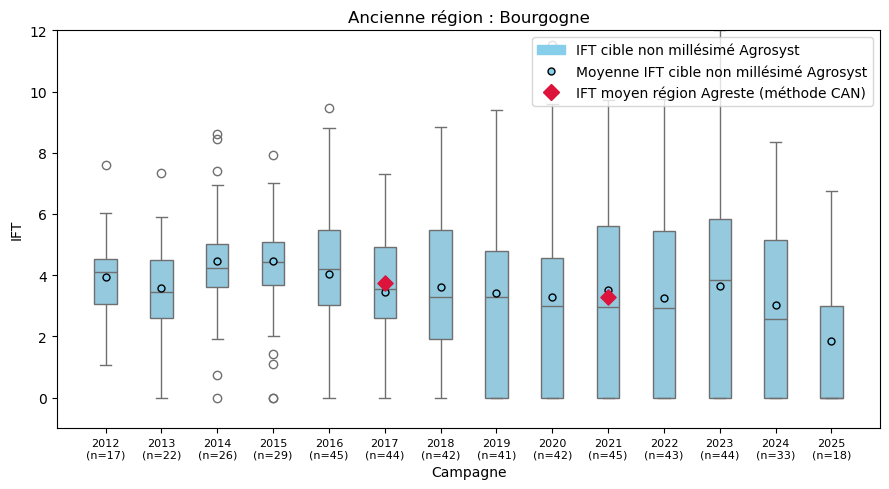

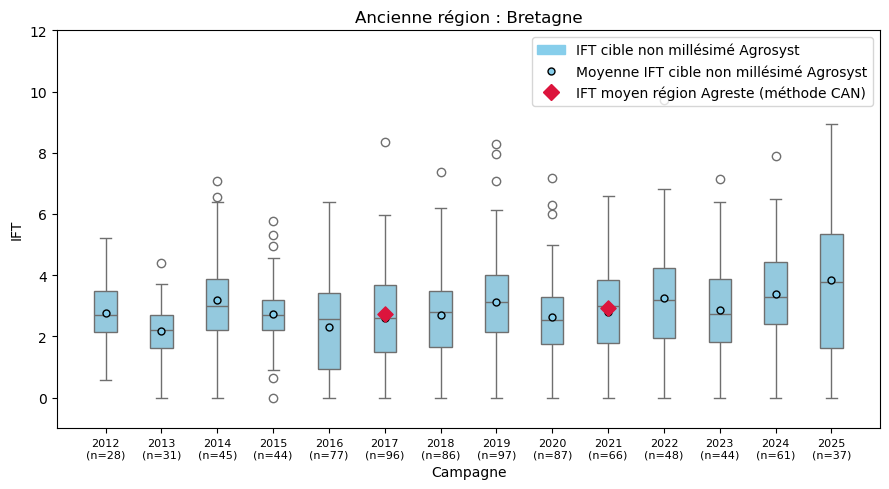

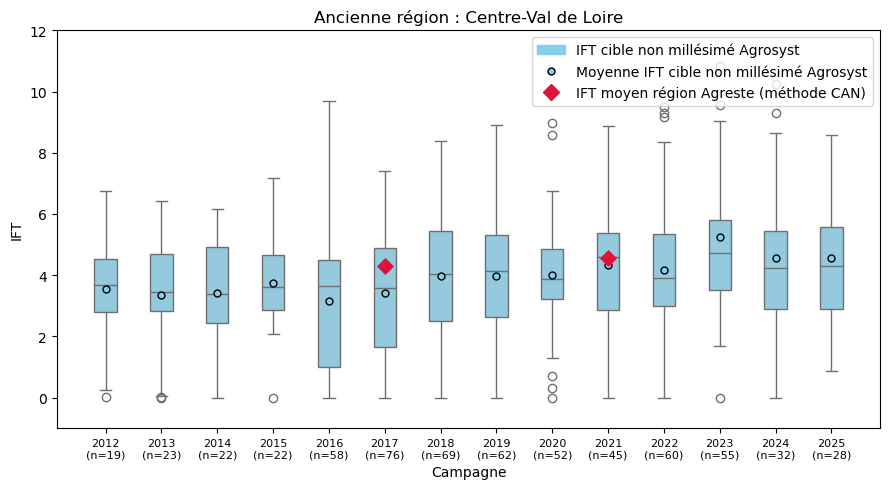

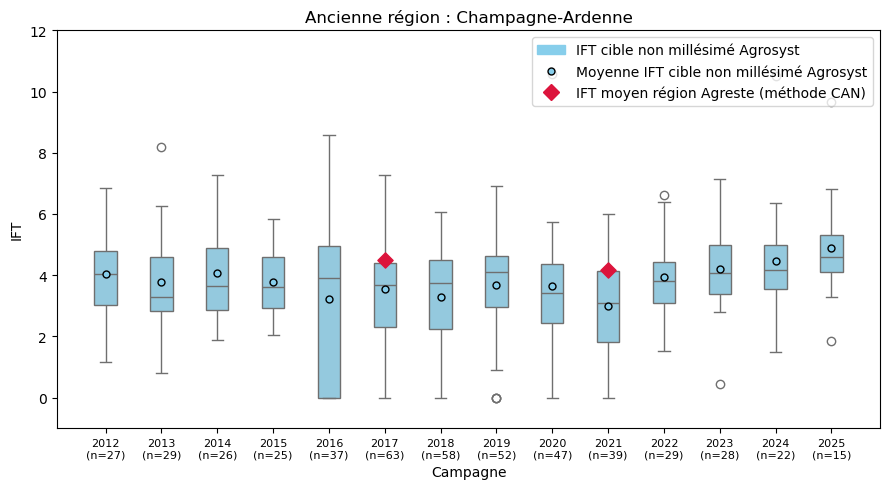

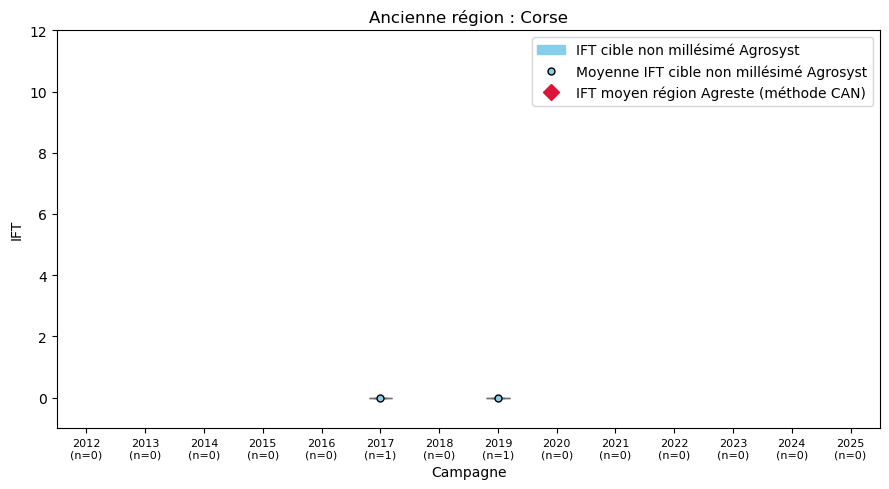

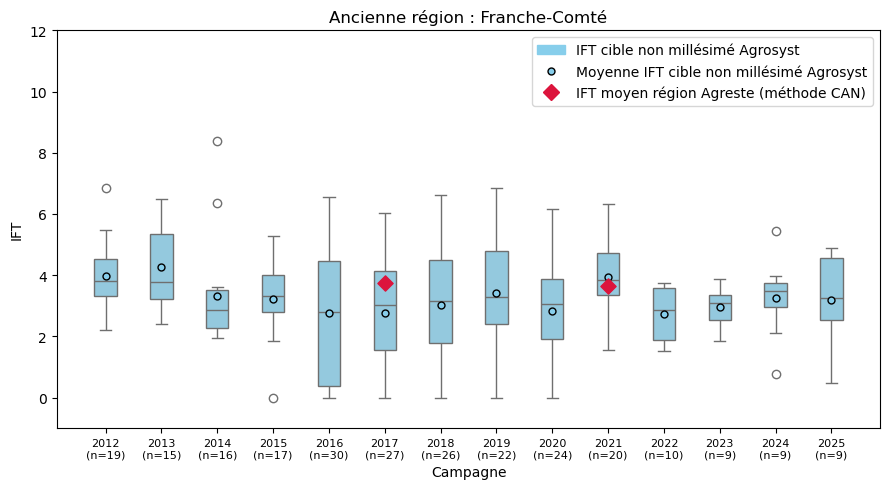

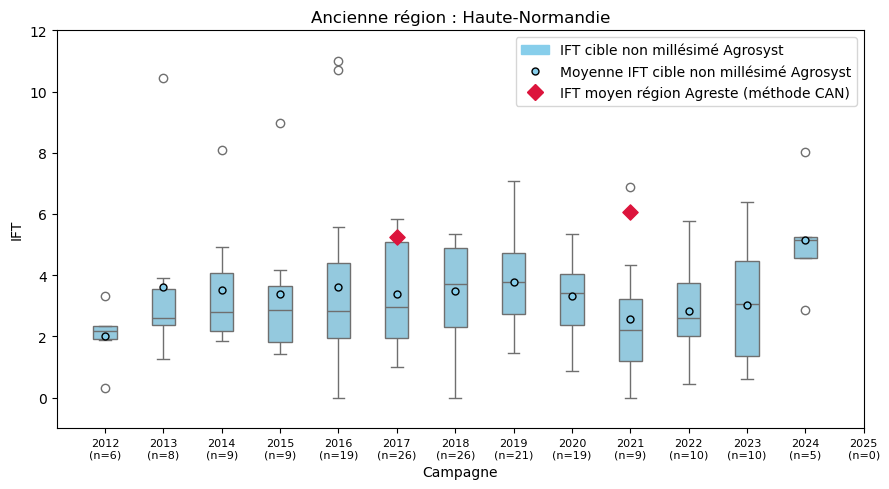

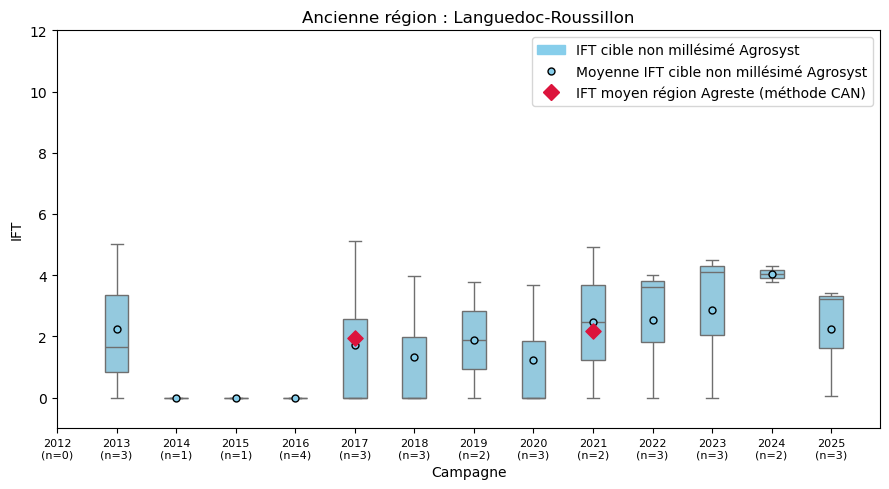

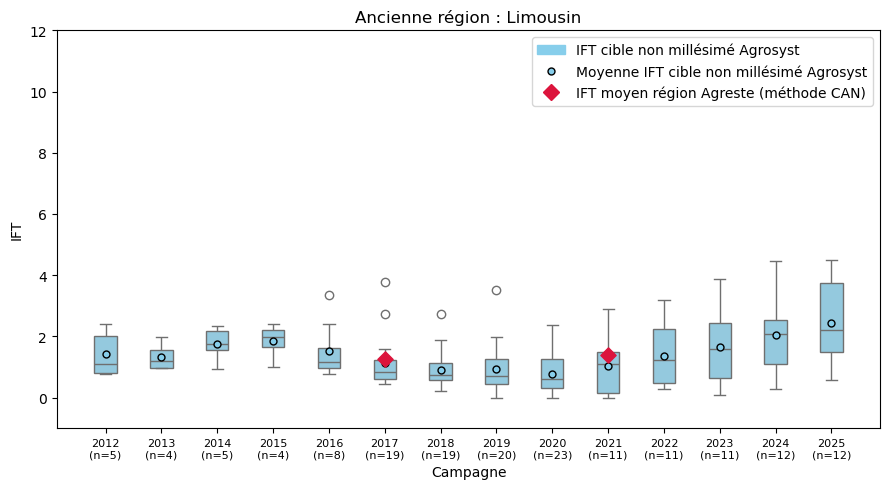

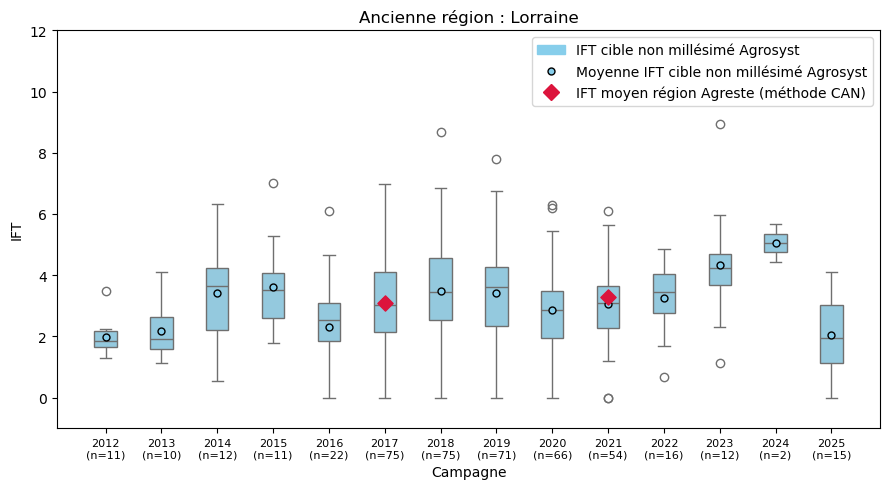

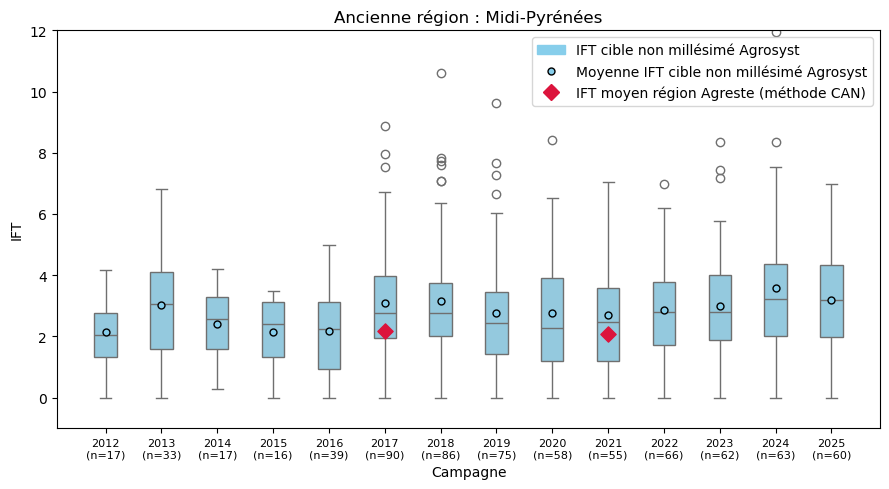

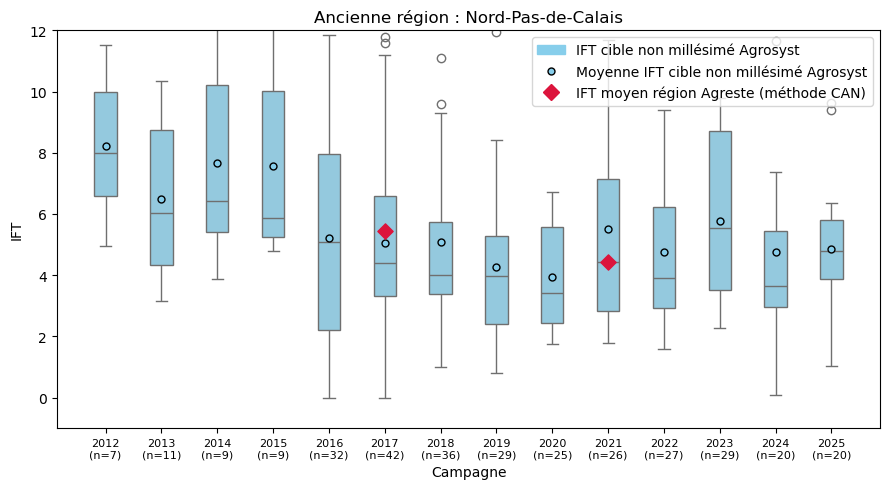

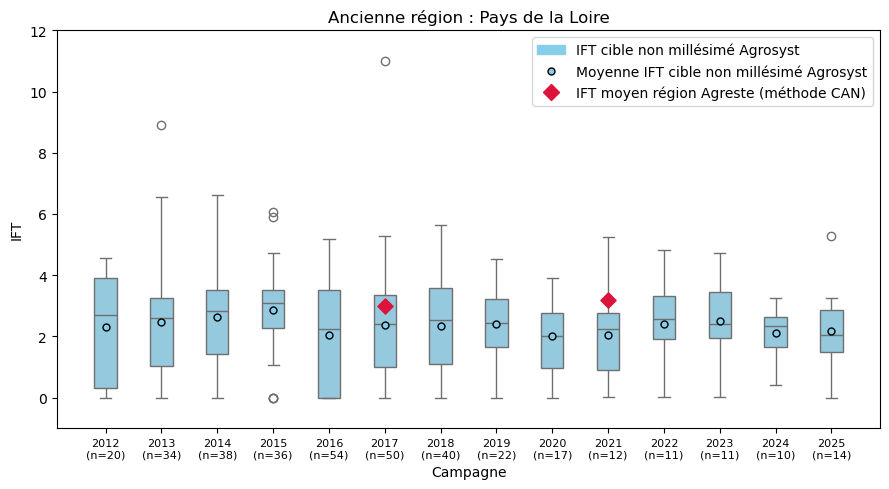

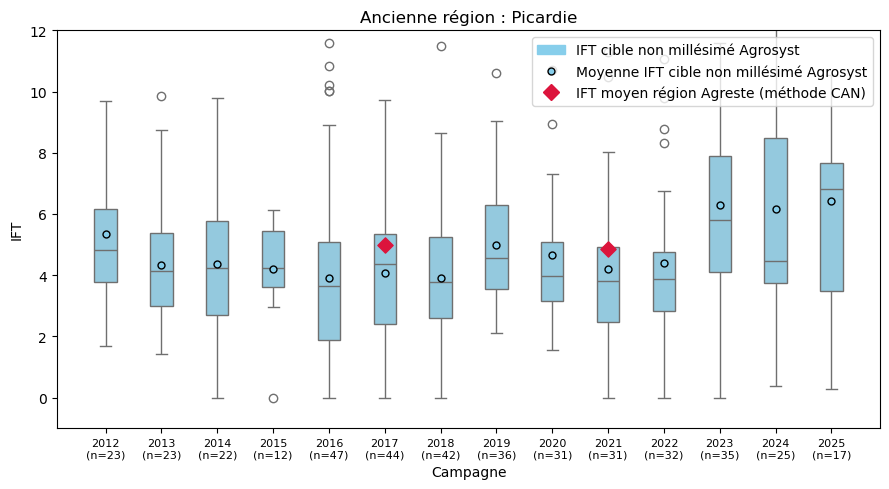

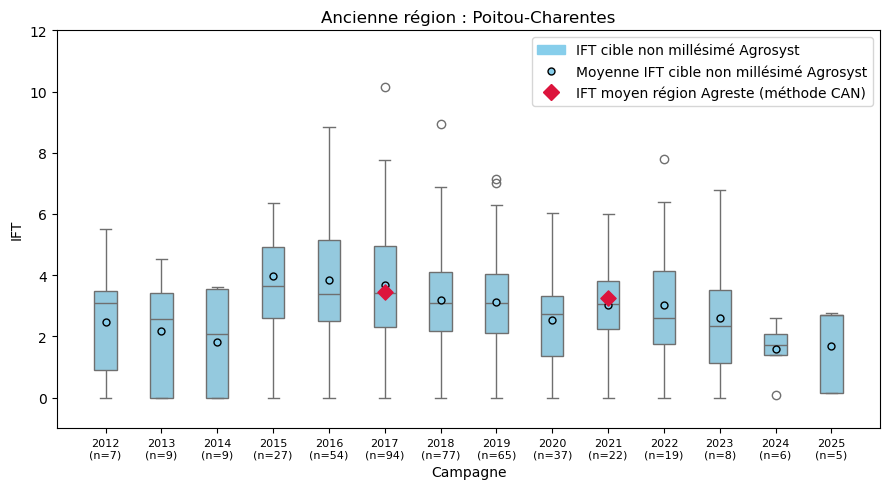

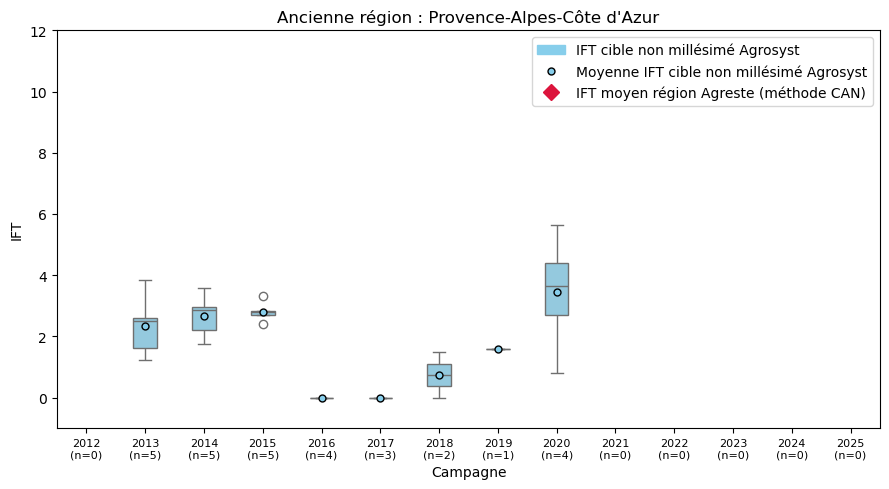

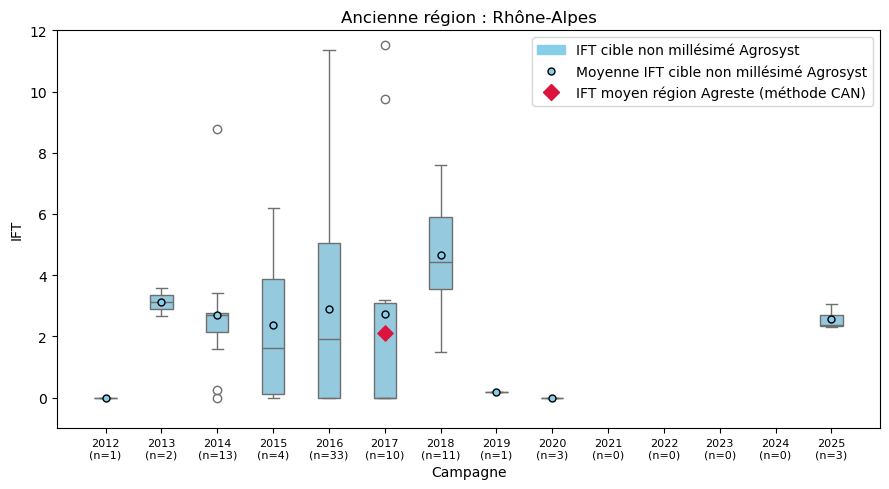

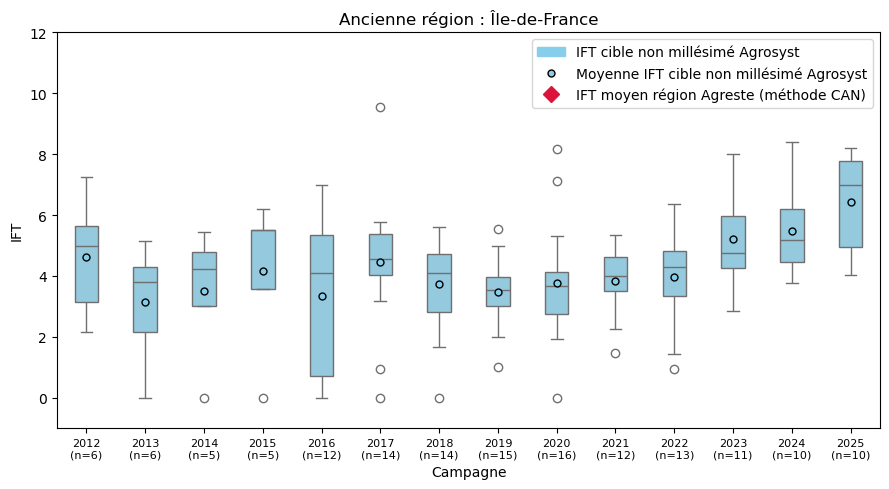

In [8]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Copie explicite et conversion de 'campagne' en string
df_data = df['sdc_realise_performance_gcpe_conv'].copy()
df_data['campagne'] = df_data['campagne'].astype(str)
df_data['ancienne_region'] = df_data['ancienne_region'].fillna(
    'Non renseignée'
)

# Ordre trié unique des campagnes (formatées en texte)
campagnes_ordred = sorted(df_data['campagne'].dropna().unique())

for region, df_region in df_data.groupby('ancienne_region'):
    fig, ax = plt.subplots(figsize=(9, 5))

    # 2. Calcul des effectifs et valeurs Agreste
    stats = (
        df_region.groupby('campagne')
        .agg(
            n=('ift_cible_non_mil_chimique_tot', 'count'),
            ift_agreste=('ift_region_agreste_can', 'first'),
        )
        .reindex(campagnes_ordred)
    )

    # 3. Boxplot
    sns.boxplot(
        data=df_region,
        x='campagne',
        y='ift_cible_non_mil_chimique_tot',
        order=campagnes_ordred,
        ax=ax,
        color='skyblue',
        width=0.4,
        showmeans=True,
        meanprops={
            'marker': 'o',
            'markerfacecolor': 'skyblue',
            'markeredgecolor': 'black',
            'markersize': 5,
        },
    )

    # 4. Superposition sécurisée des losanges (Seulement si des valeurs existent)
    x_positions = np.arange(len(campagnes_ordred))
    y_values = stats['ift_agreste'].values

    valid_mask = pd.notna(y_values)
    if valid_mask.any():
        ax.scatter(
            x=x_positions[valid_mask],
            y=y_values[valid_mask],
            color='crimson',
            marker='D',
            s=60,
            zorder=5,
        )

    # 5. Fixer les limites de l'axe Y entre 0 et 12
    ax.set_ylim(-1, 12)

    # 6. Étiquettes d'axe X avec effectifs
    labels_with_n = [
        f'{camp}\n(n={int(stats.loc[camp, "n"])})'
        if pd.notna(stats.loc[camp, 'n'])
        else f'{camp}\n(n=0)'
        for camp in campagnes_ordred
    ]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels_with_n, fontsize=8)

    # 7. Légende personnalisée
    box_patch = mpatches.Patch(
        color='skyblue', label='IFT cible non millésimé Agrosyst'
    )
    mean_circle = mlines.Line2D(
        [],
        [],
        color='skyblue',
        markeredgecolor='black',
        marker='o',
        linestyle='None',
        markersize=5,
        label='Moyenne IFT cible non millésimé Agrosyst',
    )
    mean_marker = mlines.Line2D(
        [],
        [],
        color='crimson',
        marker='D',
        linestyle='None',
        markersize=8,
        label='IFT moyen région Agreste (méthode CAN)',
    )

    ax.legend(
        handles=[box_patch, mean_circle, mean_marker], loc='upper right'
    )

    ax.set_title(f'Ancienne région : {region}')
    ax.set_xlabel('Campagne')
    ax.set_ylabel('IFT')
    plt.xticks(rotation=0)
    plt.tight_layout()

    fig.savefig(
        f'images/gcpe_conv_comparaison_agreste_agrosyst/gcpe_conv_comparaison_agreste_agrosyst_{region}.png'
    )
    plt.show()